# Classification Track — Part A
## 02. K-Nearest Neighbors (KNN)

**Notes from the algorithm list:** Tune k; discuss distance metrics.

KNN classifies a point by majority vote among its *k* nearest neighbours in feature space. Because it relies
directly on distances between points, **feature scaling is essential** — without it, large-magnitude features
like `Weight` would dominate the distance calculation over small-magnitude ones like `FCVC`. We already scaled
all numeric features in notebook `00`, so this dataset is ready for KNN as-is.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              confusion_matrix, classification_report, roc_auc_score)
from sklearn.preprocessing import label_binarize
import os

RANDOM_STATE = 42
sns.set_style("whitegrid")

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze("columns")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze("columns")
class_map = pd.read_csv("../data/processed/class_mapping.csv", index_col=0)["class_name"].to_dict()
class_names = [class_map[i] for i in sorted(class_map.keys())]

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Classes:", class_names)

X_train: (1688, 21)  X_test: (423, 21)
Classes: ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']


In [4]:
ALGO_KEY = "knn"
ALGO_DISPLAY = "K-Nearest Neighbors"

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': list(range(3, 22, 2)),
    'metric': ['euclidean', 'manhattan']
}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV weighted-F1:", round(grid.best_score_, 4))
knn = grid.best_estimator_

Best params: {'metric': 'manhattan', 'n_neighbors': 3}
Best CV weighted-F1: 0.9116


### Effect of k and distance metric (hyperparameter tuning)

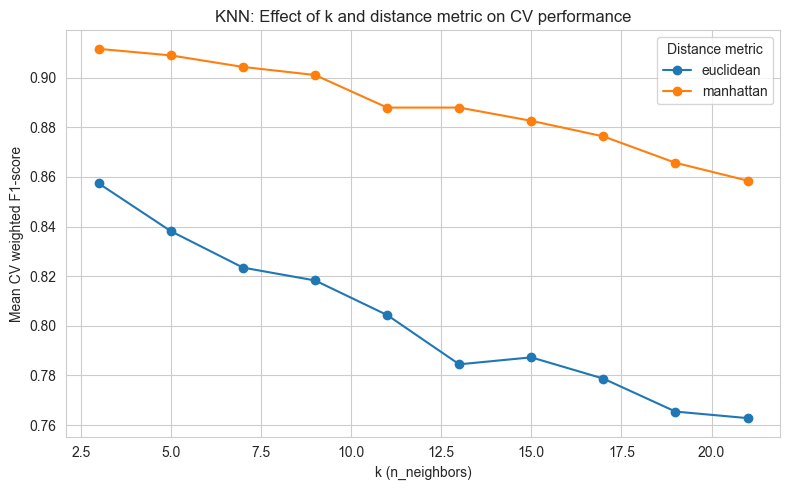

In [5]:
results_df = pd.DataFrame(grid.cv_results_)
pivot = results_df.pivot_table(index='param_n_neighbors', columns='param_metric', values='mean_test_score')

plt.figure(figsize=(8, 5))
for metric in pivot.columns:
    plt.plot(pivot.index, pivot[metric], marker='o', label=metric)
plt.xlabel("k (n_neighbors)")
plt.ylabel("Mean CV weighted F1-score")
plt.title("KNN: Effect of k and distance metric on CV performance")
plt.legend(title="Distance metric")
plt.tight_layout()
plt.savefig("../results/fig_knn_tuning.png", bbox_inches="tight")
plt.show()

**Discussion of distance metrics:** Euclidean distance measures straight-line distance and treats all feature
directions equally, while Manhattan distance sums absolute differences and is generally less sensitive to outliers
in any single feature. The grid search compares both across a range of k values and selects the combination with
the best 5-fold cross-validated weighted F1-score, reported above. Very small k tends to overfit to noise, while
very large k over-smooths the decision boundary and starts merging genuinely distinct obesity classes.

### Evaluation

In [6]:
y_pred = knn.predict(X_test)
y_proba = knn.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average='weighted')
precision_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall_weighted = recall_score(y_test, y_pred, average='weighted')

y_test_bin = label_binarize(y_test, classes=sorted(class_map.keys()))
roc_auc_ovr = roc_auc_score(y_test_bin, y_proba, multi_class='ovr', average='weighted')

print(f"Accuracy           : {acc:.4f}")
print(f"Weighted Precision  : {precision_weighted:.4f}")
print(f"Weighted Recall     : {recall_weighted:.4f}")
print(f"Weighted F1-score   : {f1_weighted:.4f}")
print(f"ROC-AUC (OvR, wtd)  : {roc_auc_ovr:.4f}")
print()
print("Full classification report:")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

Accuracy           : 0.9243
Weighted Precision  : 0.9230
Weighted Recall     : 0.9243
Weighted F1-score   : 0.9229
ROC-AUC (OvR, wtd)  : 0.9864

Full classification report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.90      0.96      0.93        54
      Normal_Weight       0.84      0.74      0.79        58
     Obesity_Type_I       0.95      1.00      0.97        70
    Obesity_Type_II       1.00      0.98      0.99        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       0.86      0.83      0.84        58
Overweight_Level_II       0.90      0.93      0.92        58

           accuracy                           0.92       423
          macro avg       0.92      0.92      0.92       423
       weighted avg       0.92      0.92      0.92       423



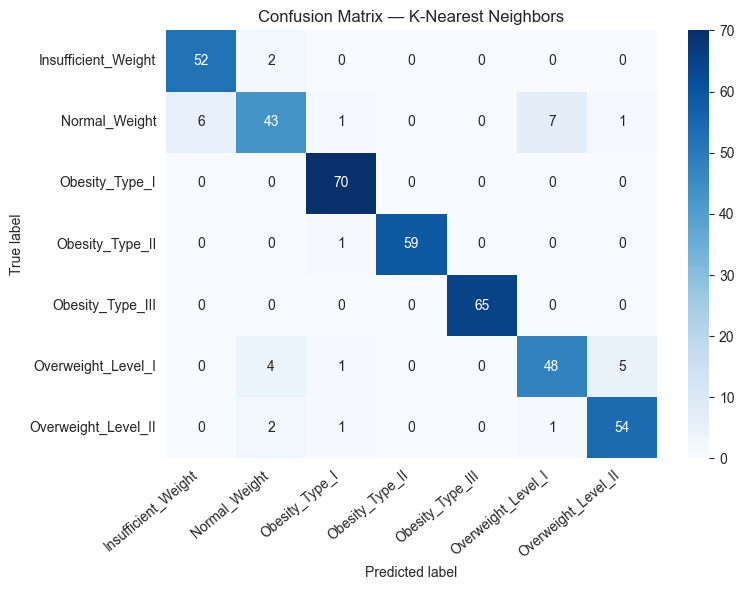

In [7]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Confusion Matrix — {ALGO_DISPLAY}")
plt.xticks(rotation=40, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"../results/fig_confusion_matrix_{ALGO_KEY}.png", bbox_inches="tight")
plt.show()

In [8]:
results_path = "../results/part_a_results.csv"
row = pd.DataFrame([{
    "Algorithm": ALGO_DISPLAY,
    "Accuracy": round(acc, 4),
    "Precision_weighted": round(precision_weighted, 4),
    "Recall_weighted": round(recall_weighted, 4),
    "F1_weighted": round(f1_weighted, 4),
    "ROC_AUC_OvR": round(roc_auc_ovr, 4),
}])

if os.path.exists(results_path):
    existing = pd.read_csv(results_path)
    existing = existing[existing["Algorithm"] != ALGO_DISPLAY]
    combined = pd.concat([existing, row], ignore_index=True)
else:
    combined = row

combined.to_csv(results_path, index=False)
print("Logged result to part_a_results.csv:")
combined

Logged result to part_a_results.csv:


,Algorithm,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,ROC_AUC_OvR
0,Naive Bayes (Gaussian),0.7447,0.7849,0.7447,0.7351,0.9497
1,Decision Tree,0.9811,0.9814,0.9811,0.9810,0.9955
2,Support Vector Machine (SVC),0.9764,0.9773,0.9764,0.9765,0.9989
3,Logistic Regression,0.9078,0.9088,0.9078,0.9071,0.9921
4,K-Nearest Neighbors,0.9243,0.9230,0.9243,0.9229,0.9864
